# Photovoltaic Figure of Merit Code Main Tutorial Notebook

At current this is only tested in inorganic semiconductor (non-perovskite) photovoltaic materials

In [1]:
#import the required modules

import placeholder.db_fom as db_fom
import placeholder.pv_fom as pv_fom
import placeholder.db_plotting as db_plotting
import placeholder.final_results as final_results
import placeholder.vasp_inputs as vasp_inputs
import numpy as np # version - 1.26.4

## Using PV-FOM to generate VASP calculation files

### Geometry Optimisation

The initial step of any DFT structural property study is a geometry optimisation to find the lowest energy position of the atoms in your system. For this you need:

- A starting structure, this can be obtained from the ICSD, materials project or experimental studies. The current code accepts VASP POSCAR/CONTCAR, .cif, .xyz or .json.
- Appropiate values for the ENCUT and KSPACING for your system. Convergence testing is the commonly used method of determining the appropiate values.
- The desired functional, it is recommended to use hybrid-DFT (HSE06 or PBE0) to achieve publishable results.

In [2]:
# Set the structure filename and calculation settings

filename = 'cdte/relaxed_primitive_POSCAR'
outdirectory = 'relax' # The folder you want to run the calculation in
functional = 'HSE06'            # The DFT functional
encut = 450                     
kspacing = 0.2

In [3]:

# Load the structure
structure = vasp_inputs.read_structure_pmg(filename)

# Generate the calculations
vasp_inputs.write_vasp_calculation(structure=structure, recipe=functional, out_dir=outdirectory, patches=['relax_cell', 'tight_relax'], user_incar_settings={"KSPACING": kspacing, "ENCUT": encut})

### Density of States 

This is required as a precursor to the optical absorption calculation that we need for much of the analysis. This time the structure we feed in is the CONTCAR from the Relaxation.

In [3]:
filename = 'relax/CONTCAR'
outdirectory = 'dos'

# Load the structure
structure = vasp_inputs.read_structure_pmg(filename)

# Generate the calculations
vasp_inputs.write_vasp_calculation(structure=structure, recipe=functional, out_dir=outdirectory, patches=["dos"], user_incar_settings={"KSPACING": kspacing, "ENCUT": encut, "ISPIN": 1, "ISMEAR": -5, "SIGMA": 0.02})

NameError: name 'functional' is not defined

#### Analysing the Density of States


In [5]:
from sumo.cli.dosplot import dosplot

dosplot(filename='Tutorial/DOS/vasprun.xml', xmin=-3, xmax=3, gaussian=0.05)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Whitney Pro, Whitney Book Extended, Catamaran, Helvetica, Liberation Sans, Andale Sans, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Whitney Pro, Whitney Book Extended, Catamaran, Helvetica, Liberation Sans, Andale Sans, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Whitney Pro, Whitney Book Extended, Catamaran, Helvetica, Liberation Sans, Andale Sans, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Whitney Pro, Whitney Book Extended, Catamaran, Helvetica, Liberation Sans, Andale Sans, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Whitney Pro, Whitney Book Extended, Catamaran, Helvetica, Liberation Sans, Andale Sans, Arial
findfont: Generic family 'sans-seri

### Optical Calculations

This can be ran in the same folder as the density of states calculation - warning it will overwrite the previous DOS INCAR in order to do so.

In [ ]:
filename = 'Tutorial/DOS/POSCAR'
outdirectory = 'Tutorial/DOS'

# Load the structure
structure = vasp_inputs.read_structure_pmg(filename)

# Generate the calculations
vasp_inputs.write_vasp_calculation(structure=structure, recipe=functional, out_dir=outdirectory, patches=["optics"], user_incar_settings={"KSPACING": kspacing, "ENCUT": encut, "ISPIN": 1, "ISMEAR": -5, "SIGMA": 0.02})

### Analysing the Optical Calculations

The initial step is using sumo to generate the required files, and plot the absorption onset.

In [20]:
# Generating the absorption.dat file and absorption onset plot, this will be saved as a PDF in the DOS folder

from sumo.cli.optplot import optplot

optplot(filenames='Tutorial/DOS/vasprun.xml', directory='Tutorial/DOS', xmax=5)

Followed by generating the SLME and Blank et.al metric.

In [24]:
# For the SLME and Blank et.al you need to run the optplot with nreal
# WARNING: it will overwrite the previous absorption spectra if you don't change the name of the file

optplot(modes=('n_real'), filenames='Tutorial/DOS/vasprun.xml', directory='Tutorial/DOS', xmax=5)

KeyError: 'l'

The Tauc Plots can then be generated

### Obtaining the Detailed Balance from Bandgap

Using the optical gaps taken from the Tauc Plots, the Detailed balance can be calculated. 

In [2]:
# Define the operating temperature of the cell, and bandgap from the Tauc plot

Tcell = 300
Egap = 1.45   # Using CdTe value

In [ ]:
# Convert the spectrum

spectrum = np.loadtxt('ASTMG173.csv', delimiter=',', skiprows=1)
photon_spectrum = db_fom.convert_spectrum(spectrum)


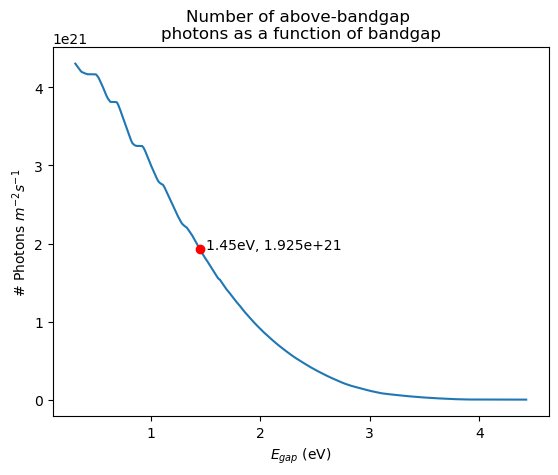

In [ ]:
# Plot the phonons above bandgap

db_plotting.photons_above_bandgap_plot(photon_spectrum, Egap)

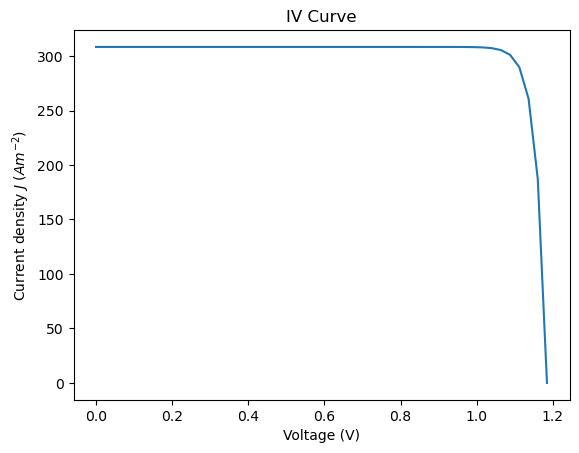

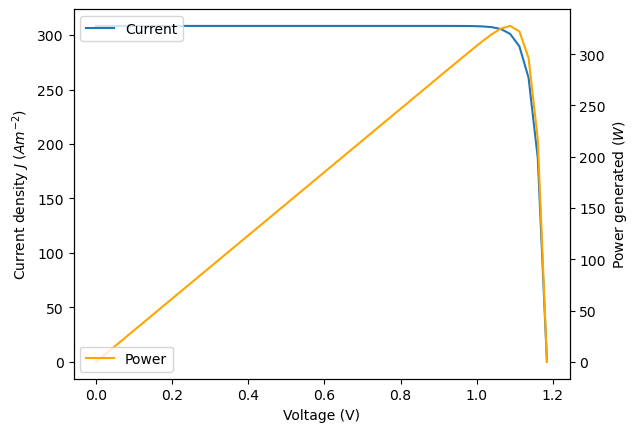

In [ ]:
# IV Curve

db_plotting.iv_curve_plot(Egap, photon_spectrum, Tcell)
db_plotting.iv_curve_plot_2(Egap, photon_spectrum, Tcell)

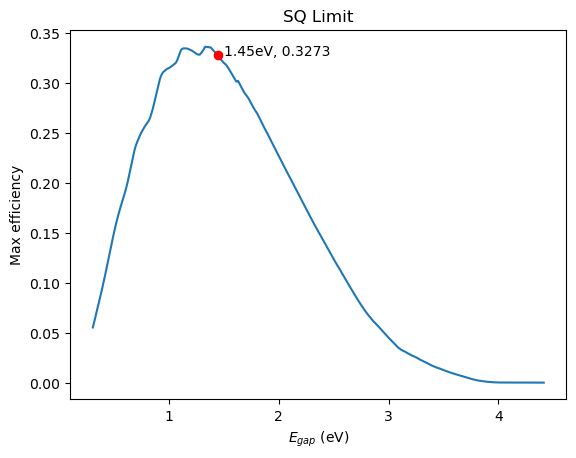

In [ ]:
# The SQ limit plot

db_plotting.sq_limit_plot(photon_spectrum, Egap, Tcell)